## 3. 지점별 평균값 비교 (바 차트)

**분석 목표:**
5개 지점의 평균값을 바 차트로 시각화하여 지점 간 수질 차이를 명확하게 비교합니다.

**분석 항목:**
DO, BOD, COD, TP, TN (5개 지표)

**한국 환경기준 (하천수, 2018.5 개정):**

| 등급 | DO | BOD | COD | TP |
|:-----:|:----:|:----:|:----:|:----:|
| Ia (매우좋음) | ≥7.5 | ≤1 | ≤2 | ≤0.02 |
| Ib (좋음) | ≥5.0 | ≤2 | ≤4 | ≤0.04 |
| II (약간좋음) | ≥5.0 | ≤3 | ≤5 | ≤0.1 |
| III (보통) | ≥5.0 | ≤5 | ≤7 | ≤0.2 |
| IV (약간나쁨) | ≥2.0 | ≤8 | ≤9 | ≤0.3 |
| V (나쁨) | ≥2.0 | ≤10 | ≤11 | ≤0.5 |
| VI (매우나쁨) | <2.0 | >10 | >11 | >0.5 |

**변경 사항:**
✅ 지점명을 약자로 변경: PD (팔당댐2), SN (성내천), BG (보광), NR (노량진), YD (영등포)

---

지점별 평균값
              DO(㎎/L)  BOD(㎎/L)  COD(㎎/L)  TP(㎎/L)  TN(㎎/L)
Site                                                       
Paldang       11.2769    1.0669    3.3025   0.0335   2.4814
Seongnae       9.3029    1.8412    4.0882   0.0846   2.6710
Bogwang        9.7062    2.1188    4.4688   0.0514   3.8137
Noryangjin    11.0438    1.9219    4.3156   0.0824   4.2611
Yeongdeungpo  10.0788    1.8424    4.3667   0.0452   3.5013



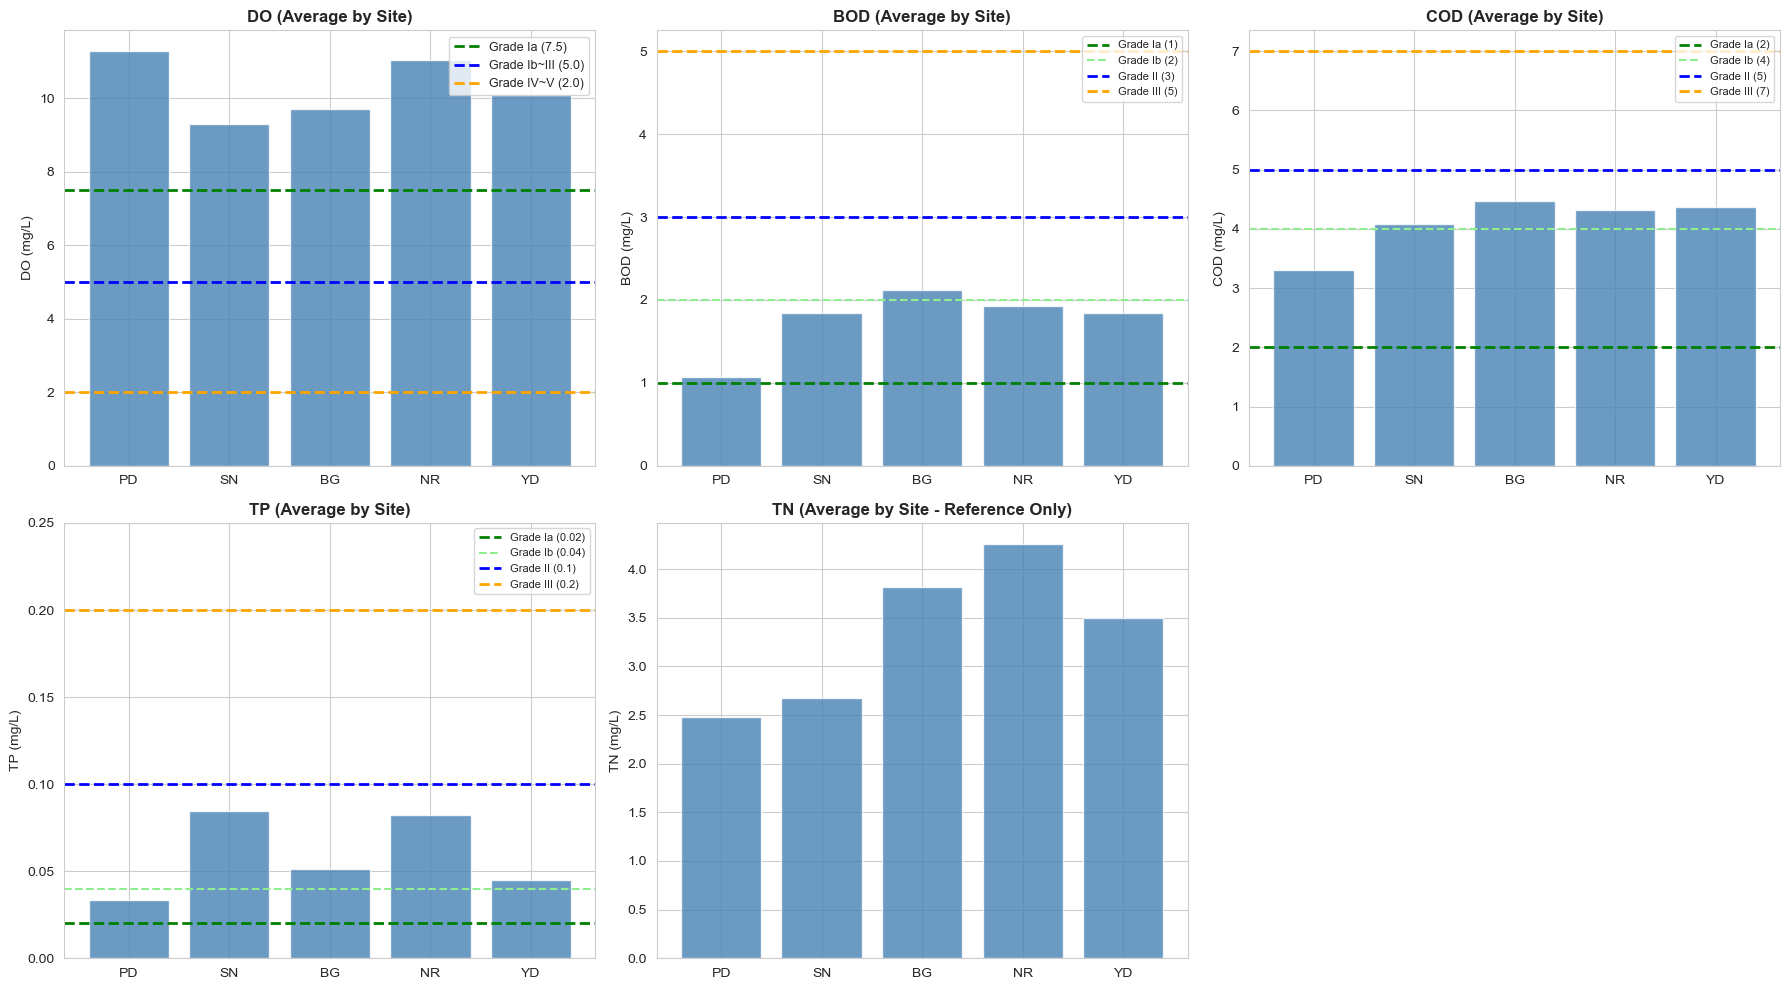

✅ Bar chart saved: 03_comparison_barchart.png

📊 지점별 평균값 비교 분석

🔹 DO (용존산소) 평균값:
   팔당댐2: 11.28 mg/L
   성내천: 9.30 mg/L
   보광: 9.71 mg/L
   노량진: 11.04 mg/L
   영등포: 10.08 mg/L

🔹 BOD (유기물 오염도) 평균값:
   팔당댐2: 1.07 mg/L
   성내천: 1.84 mg/L
   보광: 2.12 mg/L
   노량진: 1.92 mg/L
   영등포: 1.84 mg/L

🔹 COD (화학적 산소 요구량) 평균값:
   팔당댐2: 3.30 mg/L
   성내천: 4.09 mg/L
   보광: 4.47 mg/L
   노량진: 4.32 mg/L
   영등포: 4.37 mg/L

🔹 TP (총인) 평균값:
   팔당댐2: 0.0335 mg/L
   성내천: 0.0846 mg/L
   보광: 0.0514 mg/L
   노량진: 0.0824 mg/L
   영등포: 0.0452 mg/L

🔹 TN (총질소) 평균값 - 참고용:
   팔당댐2: 2.48 mg/L
   성내천: 2.67 mg/L
   보광: 3.81 mg/L
   노량진: 4.26 mg/L
   영등포: 3.50 mg/L



In [7]:
# ========== 지점별 평균값 비교 (바 차트) ==========

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# outputs 폴더 생성
os.makedirs('./outputs', exist_ok=True)

# ========== 데이터 로드 ==========
final_df = pd.read_csv('./data/processed/hangang_final.csv')

# ========== 지점명 영문 매핑 ==========
location_mapping = {
    '팔당댐2': 'Paldang',
    '노량진': 'Noryangjin',
    '보광': 'Bogwang',
    '성내천': 'Seongnae',
    '영등포': 'Yeongdeungpo'
}
final_df['Site'] = final_df['측정소명'].map(location_mapping)

# ========== 지점별 평균값 계산 ==========
average_by_site = final_df.groupby('Site')[['DO(㎎/L)', 'BOD(㎎/L)', 'COD(㎎/L)', 'TP(㎎/L)', 'TN(㎎/L)']].mean()

# 상류→하류 순서
order = ['Paldang', 'Seongnae', 'Bogwang', 'Noryangjin', 'Yeongdeungpo']
order_label = ['PD', 'SN', 'BG', 'NR', 'YD']
average_by_site = average_by_site.reindex(order)

print("=" * 70)
print("지점별 평균값")
print("=" * 70)
print(average_by_site.round(4))
print()

# ========== 5개 지표 바 차트 ==========
# 변경: 지점명을 약자로 변경 (PD, SN, BG, NR, YD)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# DO
axes[0].bar(range(len(order)), average_by_site['DO(㎎/L)'], color='steelblue', alpha=0.8)
axes[0].axhline(y=7.5, color='green', linestyle='--', linewidth=2, label='Grade Ia (7.5)', zorder=2)
axes[0].axhline(y=5.0, color='blue', linestyle='--', linewidth=2, label='Grade Ib~III (5.0)', zorder=2)
axes[0].axhline(y=2.0, color='orange', linestyle='--', linewidth=2, label='Grade IV~V (2.0)', zorder=2)
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order_label)
axes[0].set_title('DO (Average by Site)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('DO (mg/L)')
axes[0].legend(fontsize=9)

# BOD
axes[1].bar(range(len(order)), average_by_site['BOD(㎎/L)'], color='steelblue', alpha=0.8)
axes[1].axhline(y=1, color='green', linestyle='--', linewidth=2, label='Grade Ia (1)', zorder=2)
axes[1].axhline(y=2, color='lightgreen', linestyle='--', linewidth=1.5, label='Grade Ib (2)', zorder=2)
axes[1].axhline(y=3, color='blue', linestyle='--', linewidth=2, label='Grade II (3)', zorder=2)
axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Grade III (5)', zorder=2)
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order_label)
axes[1].set_title('BOD (Average by Site)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('BOD (mg/L)')
axes[1].legend(fontsize=8)

# COD
axes[2].bar(range(len(order)), average_by_site['COD(㎎/L)'], color='steelblue', alpha=0.8)
axes[2].axhline(y=2, color='green', linestyle='--', linewidth=2, label='Grade Ia (2)', zorder=2)
axes[2].axhline(y=4, color='lightgreen', linestyle='--', linewidth=1.5, label='Grade Ib (4)', zorder=2)
axes[2].axhline(y=5, color='blue', linestyle='--', linewidth=2, label='Grade II (5)', zorder=2)
axes[2].axhline(y=7, color='orange', linestyle='--', linewidth=2, label='Grade III (7)', zorder=2)
axes[2].set_xticks(range(len(order)))
axes[2].set_xticklabels(order_label)
axes[2].set_title('COD (Average by Site)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('COD (mg/L)')
axes[2].legend(fontsize=8)

# TP
axes[3].bar(range(len(order)), average_by_site['TP(㎎/L)'], color='steelblue', alpha=0.8)
axes[3].axhline(y=0.02, color='green', linestyle='--', linewidth=2, label='Grade Ia (0.02)', zorder=2)
axes[3].axhline(y=0.04, color='lightgreen', linestyle='--', linewidth=1.5, label='Grade Ib (0.04)', zorder=2)
axes[3].axhline(y=0.1, color='blue', linestyle='--', linewidth=2, label='Grade II (0.1)', zorder=2)
axes[3].axhline(y=0.2, color='orange', linestyle='--', linewidth=2, label='Grade III (0.2)', zorder=2)
axes[3].set_xticks(range(len(order)))
axes[3].set_xticklabels(order_label)
axes[3].set_title('TP (Average by Site)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('TP (mg/L)')
axes[3].set_ylim(0, 0.25)
axes[3].legend(fontsize=8)

# TN
axes[4].bar(range(len(order)), average_by_site['TN(㎎/L)'], color='steelblue', alpha=0.8)
axes[4].set_xticks(range(len(order)))
axes[4].set_xticklabels(order_label)
axes[4].set_title('TN (Average by Site - Reference Only)', fontsize=12, fontweight='bold')
axes[4].set_ylabel('TN (mg/L)')

# Hide unused subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('./outputs/03_comparison_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved: 03_comparison_barchart.png")

# ========== 📊 분석 해석 ==========
print("\n" + "=" * 70)
print("📊 지점별 평균값 비교 분석")
print("=" * 70)

location_order = ['팔당댐2', '성내천', '보광', '노량진', '영등포']
location_eng = ['Paldang', 'Seongnae', 'Bogwang', 'Noryangjin', 'Yeongdeungpo']

print("\n🔹 DO (용존산소) 평균값:")
for kr_loc, eng_loc in zip(location_order, location_eng):
    if eng_loc in average_by_site.index:
        value = average_by_site.loc[eng_loc, 'DO(㎎/L)']
        print(f"   {kr_loc}: {value:.2f} mg/L")

print("\n🔹 BOD (유기물 오염도) 평균값:")
for kr_loc, eng_loc in zip(location_order, location_eng):
    if eng_loc in average_by_site.index:
        value = average_by_site.loc[eng_loc, 'BOD(㎎/L)']
        print(f"   {kr_loc}: {value:.2f} mg/L")

print("\n🔹 COD (화학적 산소 요구량) 평균값:")
for kr_loc, eng_loc in zip(location_order, location_eng):
    if eng_loc in average_by_site.index:
        value = average_by_site.loc[eng_loc, 'COD(㎎/L)']
        print(f"   {kr_loc}: {value:.2f} mg/L")

print("\n🔹 TP (총인) 평균값:")
for kr_loc, eng_loc in zip(location_order, location_eng):
    if eng_loc in average_by_site.index:
        value = average_by_site.loc[eng_loc, 'TP(㎎/L)']
        print(f"   {kr_loc}: {value:.4f} mg/L")

print("\n🔹 TN (총질소) 평균값 - 참고용:")
for kr_loc, eng_loc in zip(location_order, location_eng):
    if eng_loc in average_by_site.index:
        value = average_by_site.loc[eng_loc, 'TN(㎎/L)']
        print(f"   {kr_loc}: {value:.2f} mg/L")

print("\n" + "=" * 70)

## 📊 분석 해석 ==========

### 🔹 DO (용존산소) 평균값 비교 ↑ (높을수록 좋음)

**수치 현황:**
- PD (팔당댐2): 11.28 mg/L → **Ia등급** ✅
- SN (성내천): 9.30 mg/L → **Ia등급** ✅
- BG (보광): 9.71 mg/L → **Ia등급** ✅
- NR (노량진): 11.04 mg/L → **Ia등급** ✅
- YD (영등포): 10.08 mg/L → **Ia등급** ✅

**특징:**
- 모든 지점이 7.5 mg/L 이상 유지(Ia등급)
- 최고값: 팔당댐2 11.28 mg/L
- 최저값: 성내천 9.30 mg/L
- 상류에서 지류로 가면서 감소

**평가:** 전 지점 Ia등급으로 산소 포화도 우수

---

### 🔹 BOD (유기물 오염도) 평균값 비교 ↓ (낮을수록 좋음)

**수치 현황:**
- PD (팔당댐2): 1.07 mg/L → **Ia등급** ✅
- SN (성내천): 1.84 mg/L → **Ib등급** ✅
- BG (보광): 2.12 mg/L → **II등급** ✅
- NR (노량진): 1.92 mg/L → **Ib등급** ✅
- YD (영등포): 1.84 mg/L → **Ib등급** ✅

**특징:**
- 최저값: 팔당댐2 1.07 mg/L (Ia등급)
- 최고값: 보광 2.12 mg/L (II등급)
- 상류에서 중류로 가면서 약 2배 증가
- 모든 지점 II등급 이내로 양호

**평가:** 증가 추세 있으나 II등급 이내로 양호

---

### 🔹 COD (화학적 산소 요구량) 평균값 비교 ↓ (낮을수록 좋음)

**수치 현황:**
- PD (팔당댐2): 3.30 mg/L → **Ib등급** ✅
- SN (성내천): 4.09 mg/L → **II등급** ✅
- BG (보광): 4.47 mg/L → **II등급** ✅
- NR (노량진): 4.32 mg/L → **II등급** ✅
- YD (영등포): 4.37 mg/L → **II등급** ✅

**특징:**
- 최저값: 팔당댐2 3.30 mg/L (Ib등급)
- 최고값: 보광 4.47 mg/L (II등급)
- 상류에서 중류로 가면서 증가 후 안정화
- 모든 지점 II등급 이내

**평가:** 중류에서 소폭 상승 후 안정화, 기준 충족

---

### 🔹 TP (총인) 평균값 비교 ↓ (낮을수록 좋음)

**수치 현황:**
- PD (팔당댐2): 0.0335 mg/L → **Ib등급** ✅
- SN (성내천): 0.0846 mg/L → **II등급** ✅
- BG (보광): 0.0514 mg/L → **II등급** ✅
- NR (노량진): 0.0824 mg/L → **II등급** ✅
- YD (영등포): 0.0452 mg/L → **II등급** ✅

**특징:**
- 최저값: 팔당댐2 0.0335 mg/L (Ib등급)
- 최고값: 성내천 0.0846 mg/L (II등급)
- 상류→하류로 가면서 약 1.35배 증가
- 지류 성내천이 가장 높음
- 모든 지점 II등급 이내로 관리 양호

**평가:** 상류→하류 증가 추세 주목 필요

---

### 🔹 TN (총질소) 평균값 비교 - 참고용 ↓ (낮을수록 좋음)

**수치 현황:**
- PD (팔당댐2): 2.48 mg/L
- SN (성내천): 2.67 mg/L
- BG (보광): 3.81 mg/L
- NR (노량진): 4.26 mg/L
- YD (영등포): 3.50 mg/L

**특징:**
- 최저값: 팔당댐2 2.48 mg/L
- 최고값: 노량진 4.26 mg/L
- 상류→하류로 가면서 뚜렷한 증가 추세
- 하천수 환경기준 없음 (참고용)

**평가:** 뚜렷한 증가 추세 (기준 없음)

---

### 박스플롯과의 비교

**박스플롯(##2)에서:**
- 분포의 형태, 변동성, 이상치 확인
- 지점별 데이터 퍼짐 파악

**바차트(##3)에서:**
- 지점별 평균값의 구체적 수치
- 최고값과 최저값 명시
- 상류→하류의 명확한 증가/감소 패턴

→ 두 분석으로 데이터 특성과 실제 수질 변화 추이를 완벽하게 파악!